In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AffinityPropagation

In [2]:
# Load dataset
dataset = pd.read_csv("Mall_Customers.csv")

In [3]:
# Select features (Annual Income and Spending Score)
X = dataset.iloc[:, [3, 4]].values

In [4]:
# Apply Affinity Propagation
ap = AffinityPropagation(random_state=42)
y_ap = ap.fit_predict(X)

In [5]:
# Add cluster labels to the dataset
dataset["Cluster"] = y_ap

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

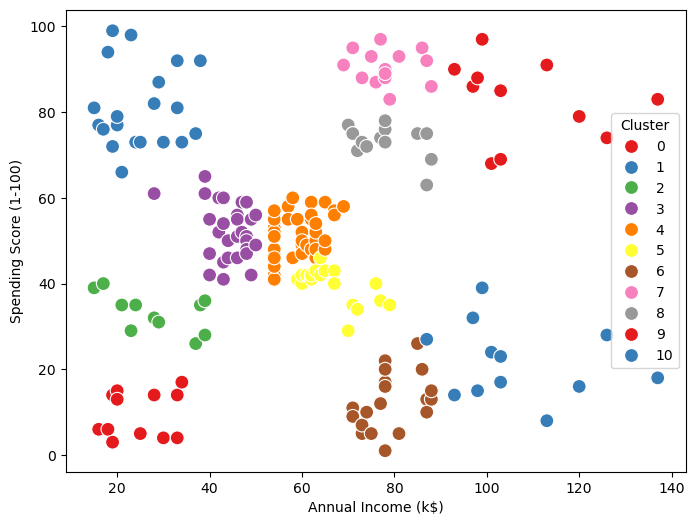

In [10]:
# Visualize clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=dataset["Annual Income (k$)"],
    y=dataset["Spending Score (1-100)"],
    hue=dataset["Cluster"],
    palette="Set1",
    s=100
)

C:\Anaconda3\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


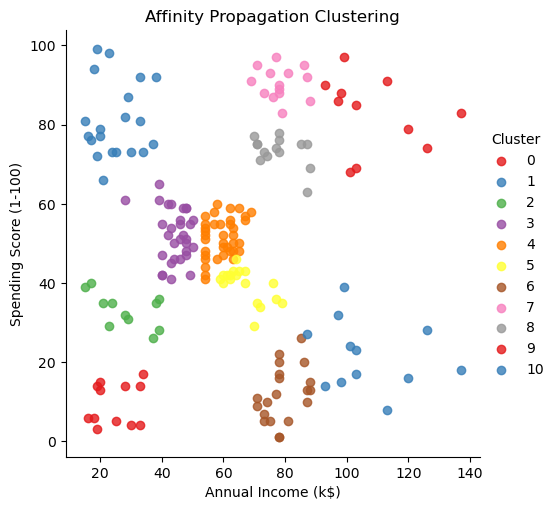

In [12]:
# Visualize with lmplot
facet = sns.lmplot(data=dataset, x=dataset.columns[3], y=dataset.columns[4], hue="Cluster",fit_reg=False,legend_out=True, palette="Set1")
plt.title("Affinity Propagation Clustering")
plt.show()

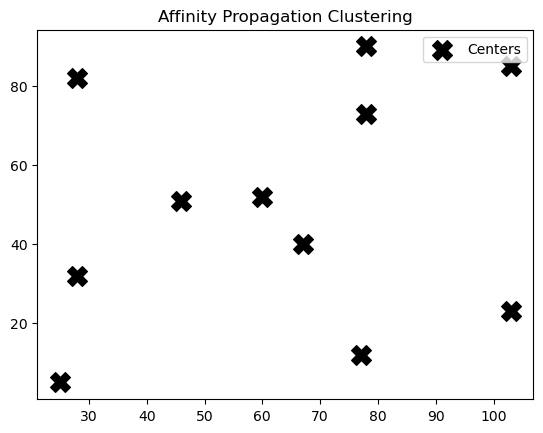

In [13]:
# Plot cluster centers (exemplars)
centers = ap.cluster_centers_
plt.scatter(
    centers[:,0], centers[:,1],
    c="black", s=200, marker="X", label="Centers"
)
plt.title("Affinity Propagation Clustering")
plt.legend()
plt.show()